In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

DATA_PATH   = r"C:\Users\Mayank Joshi\Downloads\Marketing_Channel_Project\data"
OUTPUT_PATH = os.path.join(DATA_PATH, 'cac_ltv')
os.makedirs(OUTPUT_PATH, exist_ok=True)

master = pd.read_csv(os.path.join(DATA_PATH, 'master_table.csv'))
master['first_contact_date'] = pd.to_datetime(master['first_contact_date'], errors='coerce')
master['won_date']           = pd.to_datetime(master['won_date'], errors='coerce')

print(f"Master table loaded : {master.shape[0]:,} rows x {master.shape[1]} columns")
print(f"Output folder ready : {OUTPUT_PATH}")

Master table loaded : 8,000 rows x 30 columns
Output folder ready : C:\Users\Mayank Joshi\Downloads\Marketing_Channel_Project\data\cac_ltv


In [2]:
# Three seller groups
all_leads      = master.copy()
converted      = master[master['converted'] == 1].copy()
activated      = master[master['total_orders'] > 0].copy()
not_activated  = master[(master['converted'] == 1) & (master['total_orders'] == 0)].copy()
repeat         = master[master['total_orders'] >= 3].copy()

print("SELLER POPULATION BREAKDOWN")
print("=" * 50)
print(f"\n  Total leads          : {len(all_leads):,}")
print(f"  Converted sellers    : {len(converted):,}  (signed a deal)")
print(f"  Activated sellers    : {len(activated):,}  (placed at least 1 order)")
print(f"  Never activated      : {len(not_activated):,}  (signed but never sold)")
print(f"  Repeat sellers       : {len(repeat):,}  (3+ orders)")

print(f"\n  Activation rate      : {round(len(activated)/len(converted)*100, 1)}% of converted")
print(f"  Repeat rate          : {round(len(repeat)/len(activated)*100, 1)}% of activated")

print(f"\n  Revenue summary (activated sellers only):")
print(f"  Total revenue        : ${activated['total_revenue'].sum():,.2f}")
print(f"  Avg revenue/seller   : ${activated['total_revenue'].mean():,.2f}")
print(f"  Median revenue       : ${activated['total_revenue'].median():,.2f}")
print(f"  Top seller revenue   : ${activated['total_revenue'].max():,.2f}")

SELLER POPULATION BREAKDOWN

  Total leads          : 8,000
  Converted sellers    : 842  (signed a deal)
  Activated sellers    : 380  (placed at least 1 order)
  Never activated      : 462  (signed but never sold)
  Repeat sellers       : 252  (3+ orders)

  Activation rate      : 45.1% of converted
  Repeat rate          : 66.3% of activated

  Revenue summary (activated sellers only):
  Total revenue        : $676,851.48
  Avg revenue/seller   : $1,781.19
  Median revenue       : $547.40
  Top seller revenue   : $113,628.97


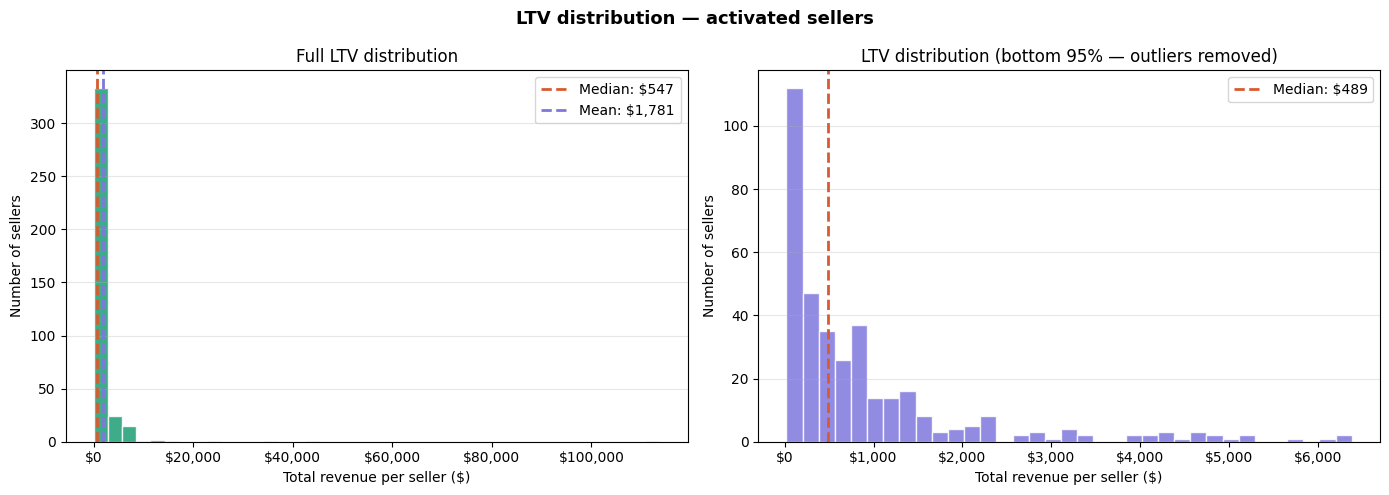

Chart saved


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LTV distribution — activated sellers', fontsize=13, fontweight='bold')

# Plot 1 — Full distribution
axes[0].hist(activated['total_revenue'], bins=40, color='#1D9E75', alpha=0.85, edgecolor='white')
axes[0].axvline(activated['total_revenue'].median(), color='#D85A30', linestyle='--',
                linewidth=2, label=f"Median: ${activated['total_revenue'].median():,.0f}")
axes[0].axvline(activated['total_revenue'].mean(), color='#7F77DD', linestyle='--',
                linewidth=2, label=f"Mean: ${activated['total_revenue'].mean():,.0f}")
axes[0].set_xlabel('Total revenue per seller ($)')
axes[0].set_ylabel('Number of sellers')
axes[0].set_title('Full LTV distribution')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Plot 2 — Remove top 5% to see the bulk distribution clearly
p95 = activated['total_revenue'].quantile(0.95)
bulk = activated[activated['total_revenue'] <= p95]
axes[1].hist(bulk['total_revenue'], bins=35, color='#7F77DD', alpha=0.85, edgecolor='white')
axes[1].axvline(bulk['total_revenue'].median(), color='#D85A30', linestyle='--',
                linewidth=2, label=f"Median: ${bulk['total_revenue'].median():,.0f}")
axes[1].set_xlabel('Total revenue per seller ($)')
axes[1].set_ylabel('Number of sellers')
axes[1].set_title('LTV distribution (bottom 95% — outliers removed)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'ltv_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [4]:
ltv_by_channel = (
    activated.groupby('origin')
    .agg(
        activated_sellers = ('seller_id', 'count'),
        total_revenue     = ('total_revenue', 'sum'),
        avg_ltv           = ('total_revenue', 'mean'),
        median_ltv        = ('total_revenue', 'median'),
        avg_orders        = ('total_orders', 'mean'),
        avg_review        = ('avg_review_score', 'mean')
    )
    .reset_index()
)

# Add total leads per channel for CAC proxy
leads_per_channel = master.groupby('origin')['mql_id'].count().reset_index()
leads_per_channel.columns = ['origin', 'total_leads']
conv_per_channel  = converted.groupby('origin')['mql_id'].count().reset_index()
conv_per_channel.columns  = ['origin', 'total_converted']

ltv_by_channel = ltv_by_channel.merge(leads_per_channel, on='origin', how='left')
ltv_by_channel = ltv_by_channel.merge(conv_per_channel, on='origin', how='left')

# CAC proxy — relative cost index
# Assumption: each lead costs equal effort to acquire
# CAC index = leads needed per activated seller
ltv_by_channel['leads_per_activation'] = (
    ltv_by_channel['total_leads'] / ltv_by_channel['activated_sellers']
).round(1)

ltv_by_channel['ltv_to_cac_index'] = (
    ltv_by_channel['avg_ltv'] / ltv_by_channel['leads_per_activation']
).round(2)

ltv_by_channel = ltv_by_channel.sort_values('avg_ltv', ascending=False)

print("LTV BY CHANNEL — UNIT ECONOMICS")
print("=" * 90)
print(f"\n{'Channel':<22} {'Active':>7} {'Avg LTV':>10} {'Median LTV':>12} "
      f"{'Leads/Active':>13} {'LTV/CAC idx':>12}")
print("-" * 90)
for _, row in ltv_by_channel.iterrows():
    print(f"  {row['origin']:<20} {int(row['activated_sellers']):>7} "
          f"${row['avg_ltv']:>8,.0f} ${row['median_ltv']:>10,.0f} "
          f"{row['leads_per_activation']:>12.0f} {row['ltv_to_cac_index']:>12.2f}")

ltv_by_channel.to_csv(os.path.join(OUTPUT_PATH, 'ltv_by_channel.csv'), index=False)
print(f"\nltv_by_channel.csv saved")

LTV BY CHANNEL — UNIT ECONOMICS

Channel                 Active    Avg LTV   Median LTV  Leads/Active  LTV/CAC idx
------------------------------------------------------------------------------------------
  other                      2 $   3,444 $     3,444           75        45.92
  unknown                   85 $   2,529 $       512           14       185.97
  referral                   9 $   1,987 $     1,368           32        62.89
  organic_search           113 $   1,832 $       634           20        90.25
  paid_search              101 $   1,537 $       512           16        97.92
  email                      6 $   1,414 $       338           82        17.20
  social                    31 $   1,403 $       722           44        32.24
  direct_traffic            31 $     707 $       399           16        43.89
  display                    2 $     462 $       462           59         7.82

ltv_by_channel.csv saved


In [5]:
ltv_by_segment = (
    activated.groupby('business_segment')
    .agg(
        sellers       = ('seller_id', 'count'),
        total_revenue = ('total_revenue', 'sum'),
        avg_ltv       = ('total_revenue', 'mean'),
        median_ltv    = ('total_revenue', 'median'),
        avg_orders    = ('total_orders', 'mean'),
        avg_review    = ('avg_review_score', 'mean')
    )
    .reset_index()
    .sort_values('avg_ltv', ascending=False)
)

print("LTV BY BUSINESS SEGMENT")
print("=" * 75)
print(f"\n{'Segment':<35} {'Sellers':>8} {'Avg LTV':>10} {'Median LTV':>12} {'Avg Orders':>12}")
print("-" * 75)
for _, row in ltv_by_segment.iterrows():
    print(f"  {row['business_segment']:<33} {int(row['sellers']):>8} "
          f"${row['avg_ltv']:>8,.0f} ${row['median_ltv']:>10,.0f} "
          f"{row['avg_orders']:>11.1f}")

ltv_by_segment.to_csv(os.path.join(OUTPUT_PATH, 'ltv_by_segment.csv'), index=False)
print(f"\nltv_by_segment.csv saved")

LTV BY BUSINESS SEGMENT

Segment                              Sellers    Avg LTV   Median LTV   Avg Orders
---------------------------------------------------------------------------
  watches                                  3 $  39,093 $     3,465       193.3
  small_appliances                         7 $   6,811 $       697         9.7
  home_appliances                          5 $   5,248 $       782        27.0
  home_office_furniture                    3 $   3,300 $     2,154        24.3
  baby                                     6 $   2,720 $       720         6.8
  pet                                     17 $   2,382 $       858        14.5
  health_beauty                           45 $   2,019 $       405        15.7
  books                                    4 $   1,764 $       435        26.0
  audio_video_electronics                 31 $   1,621 $       587         8.0
  bed_bath_table                          10 $   1,545 $       699        16.6
  music_instruments        

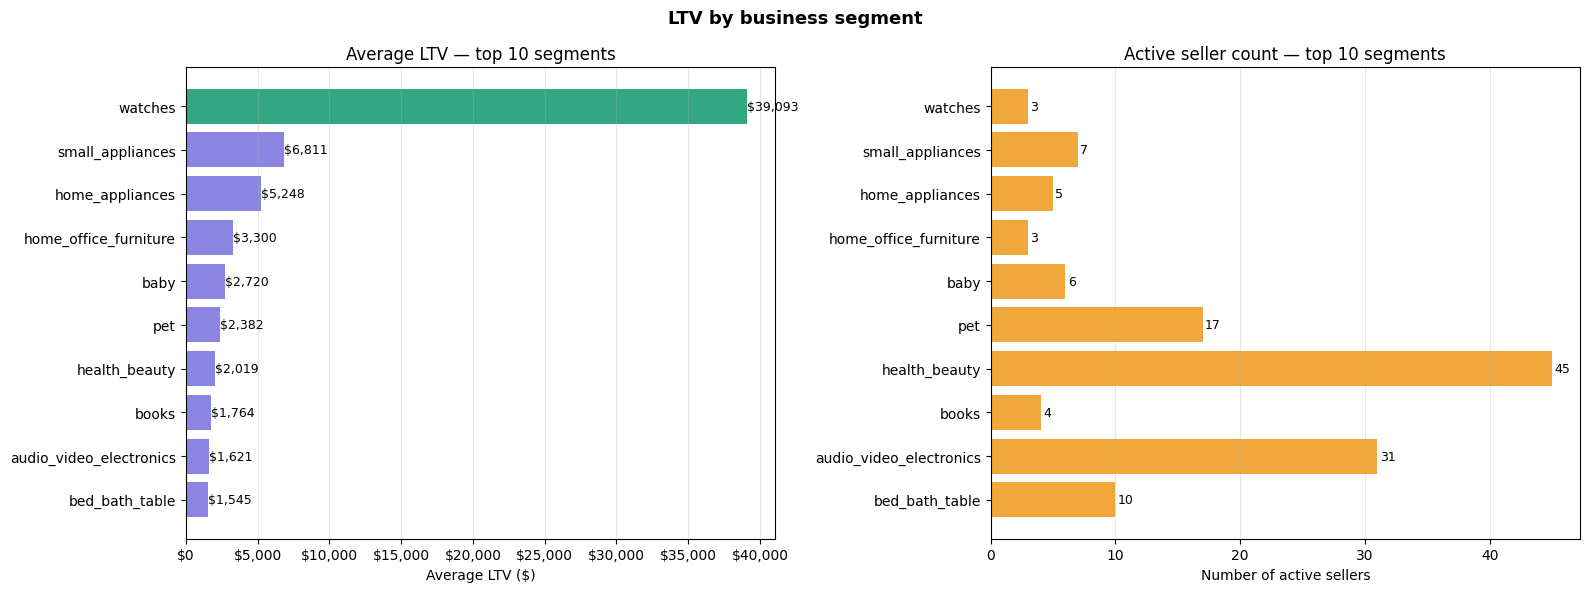

Chart saved


In [6]:
top_segments = ltv_by_segment.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LTV by business segment', fontsize=13, fontweight='bold')

colors = ['#1D9E75' if i == 0 else '#7F77DD' for i in range(len(top_segments))]

axes[0].barh(top_segments['business_segment'][::-1],
             top_segments['avg_ltv'][::-1], color=colors[::-1], alpha=0.9)
axes[0].set_xlabel('Average LTV ($)')
axes[0].set_title('Average LTV — top 10 segments')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, val in enumerate(top_segments['avg_ltv'][::-1]):
    axes[0].text(val + 10, i, f'${val:,.0f}', va='center', fontsize=9)
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(top_segments['business_segment'][::-1],
             top_segments['sellers'][::-1], color='#EF9F27', alpha=0.9)
axes[1].set_xlabel('Number of active sellers')
axes[1].set_title('Active seller count — top 10 segments')
for i, val in enumerate(top_segments['sellers'][::-1]):
    axes[1].text(val + 0.2, i, str(int(val)), va='center', fontsize=9)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'ltv_by_segment.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

PARETO ANALYSIS — REVENUE CONCENTRATION

  Total active sellers         : 380
  Sellers driving 80% revenue  : 85  (22.4%)
  Bottom 50% sellers revenue   : $39,416.97
  Top 10% sellers revenue      : $437,983.18
  Top 10% revenue share        : 64.7%


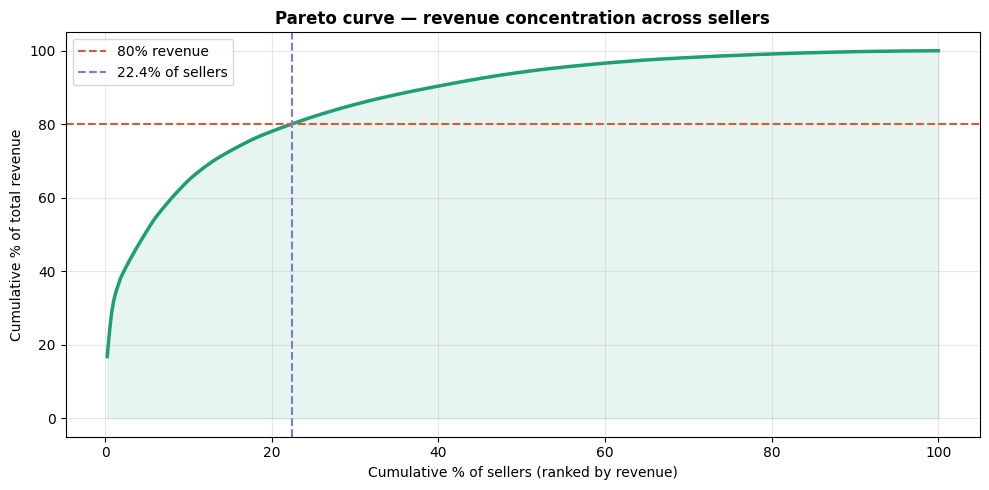

Chart saved


In [7]:
# What % of sellers drive 80% of revenue?
activated_sorted = activated.sort_values('total_revenue', ascending=False).copy()
activated_sorted['cumulative_revenue'] = activated_sorted['total_revenue'].cumsum()
activated_sorted['cumulative_pct']     = (
    activated_sorted['cumulative_revenue'] / activated_sorted['total_revenue'].sum() * 100
)
activated_sorted['seller_rank']   = range(1, len(activated_sorted) + 1)
activated_sorted['seller_pct']    = (
    activated_sorted['seller_rank'] / len(activated_sorted) * 100
)

# Find the 80% revenue threshold
threshold_80 = activated_sorted[activated_sorted['cumulative_pct'] >= 80].iloc[0]
sellers_driving_80 = threshold_80['seller_rank']
pct_sellers_80     = round(threshold_80['seller_pct'], 1)

print("PARETO ANALYSIS — REVENUE CONCENTRATION")
print("=" * 50)
print(f"\n  Total active sellers         : {len(activated_sorted):,}")
print(f"  Sellers driving 80% revenue  : {int(sellers_driving_80):,}  ({pct_sellers_80}%)")
print(f"  Bottom 50% sellers revenue   : ${activated_sorted.tail(len(activated_sorted)//2)['total_revenue'].sum():,.2f}")
print(f"  Top 10% sellers revenue      : ${activated_sorted.head(len(activated_sorted)//10)['total_revenue'].sum():,.2f}")
print(f"  Top 10% revenue share        : {round(activated_sorted.head(len(activated_sorted)//10)['total_revenue'].sum() / activated_sorted['total_revenue'].sum() * 100, 1)}%")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(activated_sorted['seller_pct'], activated_sorted['cumulative_pct'],
        color='#1D9E75', linewidth=2.5)
ax.axhline(y=80, color='#D85A30', linestyle='--', linewidth=1.5, label='80% revenue')
ax.axvline(x=pct_sellers_80, color='#7F77DD', linestyle='--', linewidth=1.5,
           label=f'{pct_sellers_80}% of sellers')
ax.fill_between(activated_sorted['seller_pct'], activated_sorted['cumulative_pct'],
                alpha=0.1, color='#1D9E75')
ax.set_xlabel('Cumulative % of sellers (ranked by revenue)')
ax.set_ylabel('Cumulative % of total revenue')
ax.set_title('Pareto curve — revenue concentration across sellers', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'pareto_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [8]:
# Classify sellers into LTV tiers
p25 = activated['total_revenue'].quantile(0.25)
p75 = activated['total_revenue'].quantile(0.75)

def ltv_tier(revenue):
    if revenue >= p75:   return 'high_ltv'
    elif revenue >= p25: return 'mid_ltv'
    else:                return 'low_ltv'

activated = activated.copy()
activated['ltv_tier'] = activated['total_revenue'].apply(ltv_tier)

tier_summary = (
    activated.groupby('ltv_tier')
    .agg(
        sellers       = ('seller_id', 'count'),
        avg_revenue   = ('total_revenue', 'mean'),
        total_revenue = ('total_revenue', 'sum'),
        avg_orders    = ('total_orders', 'mean'),
        avg_review    = ('avg_review_score', 'mean')
    )
    .reset_index()
)

print("LTV TIER ANALYSIS")
print("=" * 70)
print(f"\n  Thresholds:")
print(f"  High LTV : revenue >= ${p75:,.2f}  (top 25%)")
print(f"  Mid LTV  : revenue ${p25:,.2f} - ${p75:,.2f}")
print(f"  Low LTV  : revenue < ${p25:,.2f}   (bottom 25%)")
print(f"\n{'Tier':<12} {'Sellers':>8} {'Avg Revenue':>13} {'Total Revenue':>15} "
      f"{'Avg Orders':>12} {'Avg Review':>12}")
print("-" * 70)
for _, row in tier_summary.sort_values('avg_revenue', ascending=False).iterrows():
    print(f"  {row['ltv_tier']:<10} {int(row['sellers']):>8} "
          f"${row['avg_revenue']:>11,.0f} ${row['total_revenue']:>13,.0f} "
          f"{row['avg_orders']:>11.1f} {row['avg_review']:>11.2f}")

# Top channel per LTV tier
print(f"\n  Top acquisition channel per LTV tier:")
for tier in ['high_ltv', 'mid_ltv', 'low_ltv']:
    top_ch = activated[activated['ltv_tier']==tier]['origin'].value_counts().index[0]
    count  = activated[activated['ltv_tier']==tier]['origin'].value_counts().iloc[0]
    print(f"  {tier:<12} -> {top_ch}  ({count} sellers)")

activated.to_csv(os.path.join(OUTPUT_PATH, 'activated_sellers_ltv.csv'), index=False)
print(f"\nactivated_sellers_ltv.csv saved")

LTV TIER ANALYSIS

  Thresholds:
  High LTV : revenue >= $1,286.00  (top 25%)
  Mid LTV  : revenue $179.65 - $1,286.00
  Low LTV  : revenue < $179.65   (bottom 25%)

Tier          Sellers   Avg Revenue   Total Revenue   Avg Orders   Avg Review
----------------------------------------------------------------------
  high_ltv         95 $      5,848 $      555,535        32.2        4.13
  mid_ltv         190 $        591 $      112,374         6.7        4.26
  low_ltv          95 $         94 $        8,943         2.0        4.43

  Top acquisition channel per LTV tier:
  high_ltv     -> organic_search  (32 sellers)
  mid_ltv      -> organic_search  (54 sellers)
  low_ltv      -> organic_search  (27 sellers)

activated_sellers_ltv.csv saved


In [9]:
print("STAGE 4 COMPLETE — CAC / LTV SUMMARY")
print("=" * 55)

total_rev    = activated['total_revenue'].sum()
total_sellers = len(activated)

print(f"\n  Platform economics:")
print(f"  Total revenue generated      : ${total_rev:,.2f}")
print(f"  Active sellers               : {total_sellers}")
print(f"  Avg LTV per active seller    : ${total_rev/total_sellers:,.2f}")
print(f"  Median LTV per seller        : ${activated['total_revenue'].median():,.2f}")

print(f"\n  Funnel efficiency:")
print(f"  Leads needed per active seller    : {round(len(master)/total_sellers, 1)}")
print(f"  Leads needed per converted seller : {round(len(master)/len(converted), 1)}")
print(f"  Activation gap (signed, no orders): {len(not_activated)} sellers ({round(len(not_activated)/len(converted)*100,1)}%)")

print(f"\n  Best channel by avg LTV      : {ltv_by_channel.iloc[0]['origin']} "
      f"(${ltv_by_channel.iloc[0]['avg_ltv']:,.0f})")
print(f"  Best segment by avg LTV      : {ltv_by_segment.iloc[0]['business_segment']} "
      f"(${ltv_by_segment.iloc[0]['avg_ltv']:,.0f})")
print(f"  Revenue concentration        : top {pct_sellers_80}% of sellers = 80% of revenue")

print(f"\n  Outputs saved to: {OUTPUT_PATH}")
print(f"  Ready for Stage 5 — Segmentation")

STAGE 4 COMPLETE — CAC / LTV SUMMARY

  Platform economics:
  Total revenue generated      : $676,851.48
  Active sellers               : 380
  Avg LTV per active seller    : $1,781.19
  Median LTV per seller        : $547.40

  Funnel efficiency:
  Leads needed per active seller    : 21.1
  Leads needed per converted seller : 9.5
  Activation gap (signed, no orders): 462 sellers (54.9%)

  Best channel by avg LTV      : other ($3,444)
  Best segment by avg LTV      : watches ($39,093)
  Revenue concentration        : top 22.4% of sellers = 80% of revenue

  Outputs saved to: C:\Users\Mayank Joshi\Downloads\Marketing_Channel_Project\data\cac_ltv
  Ready for Stage 5 — Segmentation
